In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
from scipy.stats import norm
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.vector_ar.vecm import coint_johansen
import statsmodels.api as sm
from statsmodels.regression.linear_model import OLS
from statsmodels.tools import add_constant
import warnings
warnings.filterwarnings('ignore')
from itertools import combinations
import matplotlib.pyplot as plt
from pykalman import KalmanFilter

In [2]:
tickers = [
    'PETR4', 'VALE3', 'ITUB4', 'PRIO3', 'BBDC4', 'B3SA3', 'AXIA3', 'SBSP3', 
    'BBAS3', 'BPAC11', 'ITSA4', 'RENT3', 'ABEV3', 'WEGE3', 'EQTL3', 'ENEV3', 
    'RDOR3', 'SUZB3', 'LREN3', 'VBBR3', 'RADL3', 'GGBR4', 'BRAV3', 'CSMG3', 
    'TOTS3', 'CMIG4', 'RAIL3', 'CYRE3', 'CSAN3', 'VIVT3', 'UGPA3', 'CURY3', 
    'BBSE3', 'ALOS3', 'HAPV3', 'ENGI11', 'TIMS3', 'USIM5', 'CPFE3', 'MULT3', 
    'KLBN11', 'MBRF3', 'DIRR3', 'MGLU3', 'PSSA3', 'HYPE3', 'CEAB3', 'EGIE3', 
    'TAEE11', 'SANB11'
]

tickers_yfinance = [f"{ticker}.SA" for ticker in tickers]

dados_brutos = yf.download(
    tickers = tickers_yfinance,
    start="2022-07-01",
    end="2023-06-30",
    auto_adjust=True
)

df_fechamento  = dados_brutos['Close'].copy()
df_fechamento  = df_fechamento.ffill()        # ffill no fechamento
df_consolidado = np.log(df_fechamento)        # log em cima do ffill

df_consolidado.columns = [col.replace('.SA', '') for col in df_consolidado.columns]
df_consolidado.index   = df_consolidado.index.strftime('%Y-%m-%d')

print("\n--- Processamento Concluído ---")
print(f"Período : {df_consolidado.index[0]} → {df_consolidado.index[-1]}")
print(f"Matriz  : {df_consolidado.shape[0]} dias x {df_consolidado.shape[1]} ações.")
df_consolidado

[*********************100%***********************]  50 of 50 completed



--- Processamento Concluído ---
Período : 2022-07-01 → 2023-06-29
Matriz  : 249 dias x 50 ações.


,ABEV3,ALOS3,AXIA3,B3SA3,BBAS3,BBDC4,BBSE3,BPAC11,BRAV3,CEAB3,...,SUZB3,TAEE11,TIMS3,TOTS3,UGPA3,USIM5,VALE3,VBBR3,VIVT3,WEGE3
Date,,,,,,,,,,,,,,,,,,,,,
2022-07-01,2.402556,2.563498,3.691370,2.288512,2.518964,2.540844,2.858412,3.010347,3.538626,0.745862,...,3.808713,3.306959,2.219854,3.097258,2.358828,2.064748,3.970729,2.514289,2.926319,3.179759
2022-07-04,2.396725,2.567762,3.677976,2.278633,2.515640,2.530332,2.833143,2.993398,3.557828,0.705945,...,3.807125,3.290790,2.206102,3.090441,2.336336,2.060058,3.964987,2.482406,2.904205,3.179381
2022-07-05,2.426255,2.570191,3.666192,2.295636,2.510177,2.532665,2.825238,2.999676,3.480492,0.758821,...,3.777507,3.286122,2.209174,3.128609,2.325324,2.064748,3.960019,2.486067,2.901190,3.199191
2022-07-06,2.436142,2.565937,3.654267,2.281337,2.503766,2.524477,2.825238,3.016080,3.422878,0.833236,...,3.786262,3.293116,2.214528,3.166562,2.332115,2.078685,3.969396,2.481795,2.918295,3.202147
2022-07-07,2.436142,2.578645,3.666192,2.303590,2.518360,2.544821,2.835503,3.013879,3.429168,0.856859,...,3.779346,3.304410,2.245323,3.184234,2.336336,2.101491,3.998049,2.493953,2.921893,3.220792
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-06-23,2.572333,3.024106,3.563364,2.564876,3.062900,2.551178,3.106688,3.333071,3.418169,1.604892,...,3.750587,3.376457,2.450392,3.342896,2.766107,1.944330,3.915700,2.642809,2.874086,3.517742
2023-06-26,2.562603,3.011347,3.537330,2.538189,3.065249,2.546343,3.077162,3.325127,3.418812,1.593781,...,3.743378,3.370130,2.434436,3.329368,2.765002,1.951222,3.917822,2.619136,2.864206,3.513857
2023-06-27,2.565207,2.993532,3.523405,2.538901,3.046697,2.549825,3.090872,3.318792,3.393725,1.565450,...,3.726351,3.360830,2.427418,3.324590,2.750525,1.942946,3.929713,2.567696,2.865387,3.516600


In [ ]:
# Criando a matriz de correlação

matriz_correlacao = df_consolidado.corr()

# Mostra a matriz com um degradê de cores (estilo heatmap)

matriz_correlacao.style.background_gradient(cmap='coolwarm', axis=None).format(precision=2)

,ABEV3,ALOS3,AXIA3,B3SA3,BBAS3,BBDC4,BBSE3,BPAC11,BRAV3,CEAB3,CMIG4,CPFE3,CSAN3,CSMG3,CURY3,CYRE3,DIRR3,EGIE3,ENEV3,ENGI11,EQTL3,GGBR4,HAPV3,HYPE3,ITSA4,ITUB4,KLBN11,LREN3,MBRF3,MGLU3,MULT3,PETR4,PRIO3,PSSA3,RADL3,RAIL3,RDOR3,RENT3,SANB11,SBSP3,SUZB3,TAEE11,TIMS3,TOTS3,UGPA3,USIM5,VALE3,VBBR3,VIVT3,WEGE3
ABEV3,1.00,0.55,0.32,0.57,0.25,0.43,-0.22,0.72,-0.06,0.44,0.40,0.68,0.39,0.41,0.18,0.44,0.25,0.31,0.14,0.71,0.47,-0.09,0.22,0.21,0.52,0.53,0.38,0.29,0.12,0.25,0.29,0.47,0.03,0.07,0.40,0.65,0.32,0.56,0.36,0.34,0.11,0.24,0.42,0.40,0.42,0.03,-0.38,0.39,-0.01,0.10
ALOS3,0.55,1.00,0.05,0.82,0.75,0.50,-0.02,0.83,0.10,0.86,0.63,0.57,0.21,0.68,0.53,0.93,0.64,0.64,0.01,0.77,0.77,-0.05,0.10,0.35,0.83,0.83,0.60,0.22,-0.09,0.54,0.75,0.84,0.25,0.40,0.76,0.84,0.39,0.87,0.79,0.38,-0.04,0.56,0.63,0.58,0.74,0.00,-0.46,0.54,0.32,0.21
AXIA3,0.32,0.05,1.00,0.31,-0.45,0.71,-0.75,0.47,0.50,-0.05,-0.30,0.56,0.80,-0.52,-0.54,-0.07,-0.51,-0.27,0.82,0.36,-0.20,-0.37,0.92,0.50,-0.07,0.12,-0.00,0.89,0.84,0.11,-0.31,0.16,-0.39,-0.56,-0.44,-0.03,0.78,0.37,0.23,0.04,0.48,0.30,-0.39,0.24,-0.37,0.59,-0.34,0.69,0.08,-0.61
B3SA3,0.57,0.82,0.31,1.00,0.49,0.53,-0.03,0.84,0.45,0.65,0.47,0.63,0.33,0.52,0.50,0.79,0.58,0.27,0.11,0.81,0.72,0.14,0.31,0.61,0.83,0.85,0.56,0.38,0.06,0.57,0.39,0.73,0.38,0.34,0.62,0.77,0.53,0.81,0.79,0.59,0.23,0.39,0.33,0.71,0.45,0.04,-0.19,0.60,0.00,0.23
BBAS3,0.25,0.75,-0.45,0.49,1.00,0.07,0.46,0.45,-0.15,0.76,0.85,0.30,-0.07,0.79,0.68,0.76,0.74,0.70,-0.34,0.48,0.67,0.16,-0.36,0.00,0.72,0.66,0.42,-0.30,-0.43,0.47,0.81,0.76,0.40,0.69,0.84,0.75,0.02,0.54,0.60,0.20,-0.39,0.44,0.66,0.39,0.84,-0.15,-0.20,0.13,0.29,0.40
BBDC4,0.43,0.50,0.71,0.53,0.07,1.00,-0.74,0.72,0.28,0.51,0.04,0.69,0.73,-0.18,-0.30,0.46,-0.15,0.14,0.81,0.53,-0.01,-0.66,0.78,0.36,0.21,0.46,0.00,0.85,0.72,0.46,0.28,0.60,-0.48,-0.40,-0.08,0.36,0.76,0.70,0.61,-0.10,0.01,0.72,-0.05,0.37,0.05,0.52,-0.72,0.83,0.38,-0.60
BBSE3,-0.22,-0.02,-0.75,-0.03,0.46,-0.74,1.00,-0.33,-0.05,-0.07,0.44,-0.31,-0.62,0.55,0.73,0.08,0.62,0.07,-0.84,-0.07,0.44,0.77,-0.75,-0.10,0.34,0.13,0.18,-0.79,-0.81,0.05,0.14,-0.05,0.79,0.80,0.54,0.18,-0.55,-0.22,-0.07,0.35,-0.15,-0.34,0.22,0.12,0.32,-0.54,0.64,-0.57,-0.36,0.83
BPAC11,0.72,0.83,0.47,0.84,0.45,0.72,-0.33,1.00,0.21,0.70,0.47,0.78,0.57,0.41,0.19,0.73,0.30,0.46,0.36,0.87,0.54,-0.20,0.46,0.42,0.70,0.76,0.57,0.50,0.27,0.42,0.47,0.80,0.03,0.09,0.49,0.77,0.67,0.88,0.77,0.34,0.17,0.56,0.46,0.53,0.55,0.26,-0.57,0.72,0.27,-0.07
BRAV3,-0.06,0.10,0.50,0.45,-0.15,0.28,-0.05,0.21,1.00,-0.14,-0.19,0.27,0.24,-0.23,0.12,0.15,0.08,-0.49,0.26,0.23,0.15,0.23,0.55,0.76,0.30,0.42,0.12,0.49,0.31,0.48,-0.25,0.17,0.37,0.10,-0.10,0.09,0.44,0.34,0.41,0.47,0.50,0.13,-0.48,0.60,-0.32,0.12,0.28,0.42,-0.33,0.06
CEAB3,0.44,0.86,-0.05,0.65,0.76,0.51,-0.07,0.70,-0.14,1.00,0.66,0.51,0.29,0.59,0.36,0.81,0.49,0.76,0.11,0.62,0.52,-0.22,0.02,0.08,0.58,0.59,0.40,0.16,-0.00,0.50,0.76,0.80,0.01,0.23,0.67,0.75,0.37,0.73,0.67,0.07,-0.30,0.68,0.59,0.40,0.77,0.20,-0.57,0.50,0.50,-0.01


In [ ]:
# Cria uma lista para armazenar os resultados
resultados_integracao = []

# Loop para testar cada ação dentro do seu DataFrame consolidado
for coluna in df_consolidado.columns:
    serie_nivel = df_consolidado[coluna].dropna()
    serie_diff = df_consolidado[coluna].diff().dropna()
    
    # 1. Teste de Dickey-Fuller Aumentado (ADF) em NÍVEL
    # Usamos maxlag='AIC' para que o algoritmo escolha o número ideal de lags automaticamente
    adf_nivel = adfuller(serie_nivel, autolag='AIC')
    p_valor_nivel = adf_nivel[1]
    
    # 2. Teste ADF na PRIMEIRA DIFERENÇA
    adf_diff = adfuller(serie_diff, autolag='AIC')
    p_valor_diff = adf_diff[1]
    
    # 3. Lógica para determinar a Ordem de Integração
    # Se o p-valor for menor ou igual a 0.05, rejeitamos H0 (a série é estacionária)
    if p_valor_nivel <= 0.05:
        ordem = "I(0) - Estacionária em nível"
    elif p_valor_diff <= 0.05:
        ordem = "I(1) - Integrada de ordem 1"
    else:
        ordem = "I(2) ou superior"
        
    # Guardando os dados na lista
    resultados_integracao.append({
        'Ativo': coluna,
        'p-valor (Nível)': round(p_valor_nivel, 4),
        'Estacionária em Nível?': 'Sim' if p_valor_nivel <= 0.05 else 'Não',
        'p-valor (1ª Dif)': round(p_valor_diff, 4),
        'Estacionária em 1ª Dif?': 'Sim' if p_valor_diff <= 0.05 else 'Não',
        'Ordem de Integração': ordem
    })

# Transformando os resultados em um DataFrame para visualização limpa
df_resultado_final = pd.DataFrame(resultados_integracao)
df_resultado_final

,Ativo,p-valor (Nível),Estacionária em Nível?,p-valor (1ª Dif),Estacionária em 1ª Dif?,Ordem de Integração
0,ABEV3,0.0637,Não,0.0,Sim,I(1) - Integrada de ordem 1
1,ALOS3,0.9155,Não,0.0,Sim,I(1) - Integrada de ordem 1
2,AXIA3,0.6117,Não,0.0,Sim,I(1) - Integrada de ordem 1
3,B3SA3,0.3068,Não,0.0,Sim,I(1) - Integrada de ordem 1
4,BBAS3,0.7631,Não,0.0,Sim,I(1) - Integrada de ordem 1
5,BBDC4,0.5329,Não,0.0,Sim,I(1) - Integrada de ordem 1
6,BBSE3,0.2618,Não,0.0,Sim,I(1) - Integrada de ordem 1
7,BPAC11,0.8123,Não,0.0,Sim,I(1) - Integrada de ordem 1
8,BRAV3,0.2363,Não,0.0,Sim,I(1) - Integrada de ordem 1
9,CEAB3,0.8432,Não,0.0,Sim,I(1) - Integrada de ordem 1


In [5]:
cesta_definitiva = df_consolidado.drop(columns=['MGLU3', 'TOTS3'])

resultados_estacionariedade = []

for coluna in cesta_definitiva.columns:
    serie_nivel = cesta_definitiva[coluna].dropna()
    serie_diff = serie_nivel.diff().dropna()
    
    # 1. TESTES EM NÍVEL
    adf_nivel = adfuller(serie_nivel, autolag='AIC')
    kpss_nivel = kpss(serie_nivel, regression='c', nlags="auto")
    
    # 2. TESTES NA PRIMEIRA DIFERENÇA
    adf_diff = adfuller(serie_diff, autolag='AIC')
    kpss_diff = kpss(serie_diff, regression='c', nlags="auto")
    
    # Armazenando os p-valores
    resultados_estacionariedade.append({
        'Ativo': coluna,
        'ADF Nível (p-valor)': round(adf_nivel[1], 4),
        'KPSS Nível (p-valor)': round(kpss_nivel[1], 4),
        'ADF 1ª Dif (p-valor)': round(adf_diff[1], 4),
        'KPSS 1ª Dif (p-valor)': round(kpss_diff[1], 4)
    })

# Convertendo em DataFrame para exibição
df_testes_estatisticos = pd.DataFrame(resultados_estacionariedade)
df_testes_estatisticos

,Ativo,ADF Nível (p-valor),KPSS Nível (p-valor),ADF 1ª Dif (p-valor),KPSS 1ª Dif (p-valor)
0,ABEV3,0.0637,0.1000,0.0,0.1000
1,ALOS3,0.9155,0.0308,0.0,0.1000
2,AXIA3,0.6117,0.0100,0.0,0.1000
3,B3SA3,0.3068,0.1000,0.0,0.1000
4,BBAS3,0.7631,0.0100,0.0,0.1000
5,BBDC4,0.5329,0.0100,0.0,0.1000
6,BBSE3,0.2618,0.0100,0.0,0.1000
7,BPAC11,0.8123,0.1000,0.0,0.1000
8,BRAV3,0.2363,0.0415,0.0,0.1000
9,CEAB3,0.8432,0.0243,0.0,0.1000


In [6]:
# Usa a cesta_definitiva da célula anterior (já sem as I(0))
# e remove adicionalmente as que falharam no KPSS
colunas_remover = [col for col in ['ABEV3', 'B3SA3', 'BPAC11', 'CPFE3', 'ENGI11', 'HYPE3', 'ITUB4', 'PETR4', 'RENT3', 'SANB11', 'SUZB3', 'TAEE11'] if col in cesta_definitiva.columns]

cesta_johansen = cesta_definitiva.drop(columns=colunas_remover)

ativos         = cesta_johansen.columns
todos_os_pares = list(combinations(ativos, 2))
resultados_pares = []

for at1, at2 in todos_os_pares:
    df_par = cesta_johansen[[at1, at2]].dropna()
    res    = coint_johansen(df_par, det_order=0, k_ar_diff=1)

    traco_r0     = res.lr1[0];  vc_traco  = res.cvt[0, 1]
    eigen_r0     = res.lr2[0];  vc_eigen  = res.cvm[0, 1]

    cointegra_traco = traco_r0 > vc_traco
    cointegra_eigen = eigen_r0 > vc_eigen

    beta_at2 = np.round(res.evec[1, 0] / res.evec[0, 0], 4) \
               if (cointegra_traco or cointegra_eigen) else np.nan

    resultados_pares.append({
        'Ativo 1'              : at1,
        'Ativo 2'              : at2,
        'Estatística Traço'    : np.round(traco_r0, 2),
        'V.C. Traço (95%)'     : np.round(vc_traco,  2),
        'Rejeita r=0 (Traço)?': 'Sim' if cointegra_traco else 'Não',
        'Estatística Max-Eigen': np.round(eigen_r0, 2),
        'V.C. Max-Eigen (95%)' : np.round(vc_eigen,  2),
        'Rejeita r=0 (Eigen)?': 'Sim' if cointegra_eigen else 'Não',
        'Beta (Ativo 2)'       : beta_at2
    })

df_todos_os_pares = pd.DataFrame(resultados_pares)

df_pares_cointegrados = df_todos_os_pares[
    (df_todos_os_pares['Rejeita r=0 (Traço)?'] == 'Sim') |
    (df_todos_os_pares['Rejeita r=0 (Eigen)?'] == 'Sim')
].sort_values('Estatística Traço', ascending=False).reset_index(drop=True)

print(f"Pares cointegrados encontrados: {len(df_pares_cointegrados)}")
print(f"Ativos na cesta do Johansen: {len(cesta_johansen.columns)}")
df_pares_cointegrados

Pares cointegrados encontrados: 35
Ativos na cesta do Johansen: 36


,Ativo 1,Ativo 2,Estatística Traço,V.C. Traço (95%),Rejeita r=0 (Traço)?,Estatística Max-Eigen,V.C. Max-Eigen (95%),Rejeita r=0 (Eigen)?,Beta (Ativo 2)
0,USIM5,WEGE3,24.08,15.49,Sim,19.94,14.26,Sim,0.5459
1,CURY3,DIRR3,22.97,15.49,Sim,17.69,14.26,Sim,-1.2457
2,ENEV3,WEGE3,21.14,15.49,Sim,16.56,14.26,Sim,0.8533
3,EQTL3,KLBN11,21.12,15.49,Sim,18.30,14.26,Sim,-0.8842
4,CSMG3,RADL3,20.95,15.49,Sim,20.64,14.26,Sim,-1.7591
5,CURY3,USIM5,20.59,15.49,Sim,13.99,14.26,Não,3.0167
6,EQTL3,ITSA4,19.96,15.49,Sim,17.28,14.26,Sim,-1.1276
7,ITSA4,KLBN11,19.33,15.49,Sim,16.35,14.26,Sim,-0.7619
8,BBSE3,LREN3,18.68,15.49,Sim,16.18,14.26,Sim,0.5269
9,ENEV3,MBRF3,18.31,15.49,Sim,16.73,14.26,Sim,-0.5621


In [7]:
resultados_meia_vida = []

for _, linha in df_pares_cointegrados.iterrows():
    at1  = linha['Ativo 1']
    at2  = linha['Ativo 2']
    beta = linha['Beta (Ativo 2)']

    try:
        spread  = df_consolidado[at1] - (beta * df_consolidado[at2])
        spread  = spread.dropna()

        df_reg  = pd.DataFrame({
            'Y': spread.diff(),
            'X': spread.shift(1)
        }).dropna()

        modelo      = sm.OLS(df_reg['Y'], sm.add_constant(df_reg['X'])).fit()
        lambda_coef = modelo.params['X']

        hl = np.round(-np.log(2) / lambda_coef, 2) if lambda_coef < 0 else 'Divergente'

        resultados_meia_vida.append({
            'Par'                   : f"{at1} x {at2}",
            'Valor do Lambda'       : np.round(lambda_coef, 6),
            'Meia-Vida (Dias Úteis)': hl
        })
    except Exception:
        continue

df_estatistica_pares = pd.DataFrame(resultados_meia_vida)
df_estatistica_pares['_ord'] = pd.to_numeric(
    df_estatistica_pares['Meia-Vida (Dias Úteis)'], errors='coerce')
df_estatistica_pares = (df_estatistica_pares
                        .sort_values('_ord')
                        .drop(columns='_ord')
                        .reset_index(drop=True))

print(f"Meia-vida calculada para {len(df_estatistica_pares)} pares.")
df_estatistica_pares

Meia-vida calculada para 35 pares.


,Par,Valor do Lambda,Meia-Vida (Dias Úteis)
0,RDOR3 x USIM5,-0.040033,17.31
1,HAPV3 x USIM5,-0.036843,18.81
2,ENEV3 x USIM5,-0.033068,20.96
3,BBSE3 x USIM5,-0.031532,21.98
4,PRIO3 x USIM5,-0.031195,22.22
5,PSSA3 x USIM5,-0.029448,23.54
6,SBSP3 x USIM5,-0.029357,23.61
7,CURY3 x USIM5,-0.027059,25.62
8,DIRR3 x USIM5,-0.026980,25.69
9,BBDC4 x SBSP3,-0.023520,29.47


In [ ]:
def calcular_hurst_estavel(serie):
    """
    Calcula o Expoente de Hurst através da abordagem de variância dos lags,
    evitando divisões instáveis em sub-blocos e garantindo limites reais [0, 1].
    """
    serie = np.asarray(serie)
    n = len(serie)
    if n < 100:
        return np.nan
        
    # Define lags seguros (escalas de tempo macro, de 10 dias até um quarto da amostra)
    lags = np.unique(np.logspace(1, np.log10(n // 4), num=15).astype(int))
    
    variancias = []
    for lag in lags:
        # Calcula a diferença da série temporal escalada no lag correspondente
        dif = serie[lag:] - serie[:-lag]
        # Armazena a variância dessa diferença
        variancias.append(np.var(dif))
        
    # Em escalas de tempo financeiras, a Variância do Spread é proporcional a lag^(2H)
    # Logo: log(Variância) = 2H * log(lag) + C
    if len(variancias) < 2:
        return np.nan
        
    coeffs = np.polyfit(np.log(lags), np.log(variancias), 1)
    
    # O coeficiente angular é igual a 2H. Logo, Hurst = Coeffs[0] / 2
    h_estimado = coeffs[0] / 2
    
    # Limitador de segurança econométrica para manter a fronteira teórica [0, 1]
    return np.clip(h_estimado, 0.0001, 0.9999)

# ==============================================================================
# LOOP CORRIGIDO PARA OS PARES
# ==============================================================================
resultados_hurst = []

print(f"Calculando o Expoente de Hurst para {len(df_pares_cointegrados)} pares...")

for indice, linha in df_pares_cointegrados.iterrows():
    at1 = linha['Ativo 1']
    at2 = linha['Ativo 2']
    beta = linha['Beta (Ativo 2)']
    
    try:
        # Spread: S_t = P1_t - beta * P2_t  
        spread = df_consolidado[at1] - (beta * df_consolidado[at2])
        spread = spread.dropna()
        
        # Calcula o Hurst robusto
        h_score = calcular_hurst_estavel(spread)
        
        resultados_hurst.append({
            'Par': f"{at1} x {at2}",
            'Estatística Traço': linha['Estatística Traço'],
            'Beta': beta,
            'Expoente de Hurst (H)': np.round(h_score, 4)
        })
    except Exception:
        continue

df_pares_hurst = pd.DataFrame(resultados_hurst)

# Ordena do menor Hurst (maior força de reversão) para o maior
df_pares_hurst = df_pares_hurst.sort_values(by='Expoente de Hurst (H)', ascending=True).reset_index(drop=True)

df_pares_hurst

Calculando o Expoente de Hurst para 35 pares...


,Par,Estatística Traço,Beta,Expoente de Hurst (H)
0,ENEV3 x USIM5,15.56,-2.1633,0.2799
1,HAPV3 x USIM5,15.74,-9.5033,0.2859
2,PSSA3 x USIM5,17.57,2.2149,0.3018
3,RDOR3 x USIM5,16.67,-3.4367,0.3093
4,DIRR3 x USIM5,17.32,2.3337,0.3134
5,BBSE3 x USIM5,15.84,2.0172,0.3275
6,ENEV3 x MBRF3,18.31,-0.5621,0.3383
7,CURY3 x USIM5,20.59,3.0167,0.3517
8,PRIO3 x USIM5,16.75,3.6216,0.3633
9,KLBN11 x RADL3,16.72,-0.8093,0.3878


In [ ]:
# 1. Cria uma cópia da tabela base do Johansen
df_base = df_pares_cointegrados[['Ativo 1', 'Ativo 2', 'Estatística Traço', 'Estatística Max-Eigen', 'Beta (Ativo 2)']].copy()


df_base['Par'] = df_base['Ativo 1'] + ' x ' + df_base['Ativo 2']

# 2. Isola as colunas de métricas das outras tabelas
df_mv_isolado = df_estatistica_pares[['Par', 'Meia-Vida (Dias Úteis)']]
df_hurst_isolado = df_pares_hurst[['Par', 'Expoente de Hurst (H)']]

# 3. Faz o cruzamento inteligente (PROCV) baseado na coluna 'Par' que agora existe em todas
df_ultimo = pd.merge(df_base, df_mv_isolado, on='Par', how='left')
df_ultimo = pd.merge(df_ultimo, df_hurst_isolado, on='Par', how='left')

# 4. Reorganiza a ordem das colunas para ficar visualmente perfeito para o TCC
df_ultimo = df_ultimo[[
    'Par', 'Ativo 1', 'Ativo 2', 
    'Estatística Traço', 'Estatística Max-Eigen', 
    'Beta (Ativo 2)', 'Meia-Vida (Dias Úteis)', 'Expoente de Hurst (H)'
]]

# 5. Ordena o resultado final pelo menor Expoente de Hurst (H)
df_ultimo = df_ultimo.sort_values(by='Expoente de Hurst (H)', ascending=True).reset_index(drop=True)

# Exibe a tabela final unificada
df_ultimo

,Par,Ativo 1,Ativo 2,Estatística Traço,Estatística Max-Eigen,Beta (Ativo 2),Meia-Vida (Dias Úteis),Expoente de Hurst (H)
0,ENEV3 x USIM5,ENEV3,USIM5,15.56,13.32,-2.1633,20.96,0.2799
1,HAPV3 x USIM5,HAPV3,USIM5,15.74,13.78,-9.5033,18.81,0.2859
2,PSSA3 x USIM5,PSSA3,USIM5,17.57,14.48,2.2149,23.54,0.3018
3,RDOR3 x USIM5,RDOR3,USIM5,16.67,12.14,-3.4367,17.31,0.3093
4,DIRR3 x USIM5,DIRR3,USIM5,17.32,13.17,2.3337,25.69,0.3134
5,BBSE3 x USIM5,BBSE3,USIM5,15.84,10.60,2.0172,21.98,0.3275
6,ENEV3 x MBRF3,ENEV3,MBRF3,18.31,16.73,-0.5621,70.91,0.3383
7,CURY3 x USIM5,CURY3,USIM5,20.59,13.99,3.0167,25.62,0.3517
8,PRIO3 x USIM5,PRIO3,USIM5,16.75,12.99,3.6216,22.22,0.3633
9,KLBN11 x RADL3,KLBN11,RADL3,16.72,14.06,-0.8093,86.39,0.3878


In [ ]:
# ==============================================================================
# FILTRAGEM DO GRUPO DE PARES PARA BACKTEST
# ==============================================================================

# 1. Garantimos que a coluna de Meia-Vida seja lida como número (excluindo os "Divergente")
df_ultimo['Meia-Vida (Dias Úteis)'] = pd.to_numeric(df_ultimo['Meia-Vida (Dias Úteis)'], errors='coerce')

# 2. Aplicamos as três condições simultaneamente:
#    - Estatística Traço > 15.49 (Significância de Johansen)
#    - Meia-Vida < 30 dias úteis (Velocidade comercial de reversão)
#    - Expoente de Hurst < 0.50 (Anticorrelação local confirmada)
condicao_traco = df_ultimo['Estatística Traço'] > 15.49
condicao_mv = df_ultimo['Meia-Vida (Dias Úteis)'] < 30
condicao_hurst = df_ultimo['Expoente de Hurst (H)'] < 0.50
#condicao_beta  = df_ultimo['Beta (Ativo 2)'].abs() <= 10

# 3. Cria o DataFrame filtrado com os pares eleitos (os seus "Pares Verdes")
df_pares_selecionados = df_ultimo[condicao_traco & condicao_mv & condicao_hurst].reset_index(drop=True)

# 4. Ordena pelo menor Hurst para garantir que os mais eficientes fiquem no topo
df_pares_selecionados = df_pares_selecionados.sort_values(by='Expoente de Hurst (H)', ascending=True).reset_index(drop=True)

print(f"Sucesso! Foram selecionados {len(df_pares_selecionados)} pares que cumprem todos os requisitos rigorosos.")

# Exibe a lista finalizada que irá para o robô de backtest
df_pares_selecionados

Sucesso! Foram selecionados 10 pares que cumprem todos os requisitos rigorosos.


,Par,Ativo 1,Ativo 2,Estatística Traço,Estatística Max-Eigen,Beta (Ativo 2),Meia-Vida (Dias Úteis),Expoente de Hurst (H)
0,ENEV3 x USIM5,ENEV3,USIM5,15.56,13.32,-2.1633,20.96,0.2799
1,HAPV3 x USIM5,HAPV3,USIM5,15.74,13.78,-9.5033,18.81,0.2859
2,PSSA3 x USIM5,PSSA3,USIM5,17.57,14.48,2.2149,23.54,0.3018
3,RDOR3 x USIM5,RDOR3,USIM5,16.67,12.14,-3.4367,17.31,0.3093
4,DIRR3 x USIM5,DIRR3,USIM5,17.32,13.17,2.3337,25.69,0.3134
5,BBSE3 x USIM5,BBSE3,USIM5,15.84,10.60,2.0172,21.98,0.3275
6,CURY3 x USIM5,CURY3,USIM5,20.59,13.99,3.0167,25.62,0.3517
7,PRIO3 x USIM5,PRIO3,USIM5,16.75,12.99,3.6216,22.22,0.3633
8,SBSP3 x USIM5,SBSP3,USIM5,17.71,12.81,1.3304,23.61,0.4332
9,BBDC4 x SBSP3,BBDC4,SBSP3,16.09,11.61,2.7125,29.47,0.4987


In [ ]:
# 1. Filtra os preços do consolidado para o período de estimação
df_est = df_consolidado.loc['2022-07-01':'2023-06-30'].copy()

# Dicionário simples para guardar as séries
series_pares = {}

# 2. Loop direto que passa apenas pelos pares selecionados do df_pares_filtrados
for indice, linha in df_pares_selecionados.iterrows():
    par_nome = linha['Par']
    at1 = linha['Ativo 1']
    at2 = linha['Ativo 2']
    beta = linha['Beta (Ativo 2)']
    
    # 3. Calcula o Spread e o Z-Score
    spread = df_est[at1] - (beta * df_est[at2])
    zscore = (spread - spread.mean()) / spread.std()
    
    # 4. Adiciona direto no dicionário com nomes claros para as colunas
    series_pares[f"{par_nome}_Spread"] = spread
    series_pares[f"{par_nome}_Z-Score"] = zscore

# 5. Transforma no DataFrame final
df_historico_estimacao = pd.DataFrame(series_pares)

# Exibe o resultado final na tela
df_historico_estimacao

,ENEV3 x USIM5_Spread,ENEV3 x USIM5_Z-Score,HAPV3 x USIM5_Spread,HAPV3 x USIM5_Z-Score,PSSA3 x USIM5_Spread,PSSA3 x USIM5_Z-Score,RDOR3 x USIM5_Spread,RDOR3 x USIM5_Z-Score,DIRR3 x USIM5_Spread,DIRR3 x USIM5_Z-Score,BBSE3 x USIM5_Spread,BBSE3 x USIM5_Z-Score,CURY3 x USIM5_Spread,CURY3 x USIM5_Z-Score,PRIO3 x USIM5_Spread,PRIO3 x USIM5_Z-Score,SBSP3 x USIM5_Spread,SBSP3 x USIM5_Z-Score,BBDC4 x SBSP3_Spread,BBDC4 x SBSP3_Z-Score
Date,,,,,,,,,,,,,,,,,,,,
2022-07-01,7.184009,1.403188,24.056297,1.078114,-1.883907,-1.861037,10.297935,0.881393,-3.914236,-2.056080,-1.306597,-1.787525,-4.717325,-2.222255,-4.383717,-1.800007,-0.729621,-1.857785,-2.931135,1.834177
2022-07-04,7.142328,1.251358,24.083805,1.105264,-1.883565,-1.859728,10.288422,0.856071,-3.911584,-2.047280,-1.322406,-1.853382,-4.722410,-2.234937,-4.335990,-1.683475,-0.746912,-1.959114,-2.877820,2.009198
2022-07-05,7.161971,1.322911,24.156126,1.176647,-1.864115,-1.785307,10.313160,0.921919,-3.902380,-2.016748,-1.339770,-1.925718,-4.723695,-2.238141,-4.426710,-1.904978,-0.767057,-2.077161,-2.837768,2.140682
2022-07-06,7.208197,1.491301,24.304554,1.323148,-1.909239,-1.957968,10.387492,1.119775,-3.912494,-2.050298,-1.367885,-2.042836,-4.753042,-2.311329,-4.490500,-2.060730,-0.782947,-2.170278,-2.853150,2.090187
2022-07-07,7.264156,1.695143,24.570755,1.585895,-1.956995,-2.140698,10.477256,1.358708,-3.922344,-2.082976,-1.403625,-2.191718,-4.756218,-2.319251,-4.557421,-2.224124,-0.794917,-2.240422,-2.882638,1.993384
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-06-23,6.717394,-0.296561,22.651173,-0.308773,-1.152880,0.936100,10.045729,0.210077,-3.004002,0.963549,-0.815415,0.258601,-3.443773,0.953879,-3.400095,0.601615,-0.281510,0.768133,-3.701750,-0.695619
2023-06-26,6.705152,-0.341155,22.664524,-0.295596,-1.163469,0.895582,10.059173,0.245862,-3.041287,0.839857,-0.858844,0.077691,-3.491002,0.836092,-3.456153,0.464743,-0.306223,0.623320,-3.664423,-0.573080
2023-06-27,6.667029,-0.480027,22.578549,-0.380455,-1.131596,1.017539,10.009620,0.113962,-3.038595,0.848789,-0.828439,0.204348,-3.474106,0.878230,-3.460231,0.454786,-0.289220,0.722958,-3.677196,-0.615014


In [12]:
# ── Download do período de trading ───────────────────────────────────────────
tickers_yf = list(set(
    [f"{t}.SA" for t in df_pares_selecionados['Ativo 1'].tolist() +
                        df_pares_selecionados['Ativo 2'].tolist()]
))

dados_trad = yf.download(tickers=tickers_yf, start="2023-07-01",
                          end="2023-12-31", auto_adjust=True, progress=False)

df_trad = np.log(dados_trad['Close'].ffill())
df_trad.columns = [c.replace('.SA', '') for c in df_trad.columns]
df_trad.index   = df_trad.index.strftime('%Y-%m-%d')

# ── Kalman + Spread estático + Z-Score ───────────────────────────────────────
series_trading = {}

for _, linha in df_pares_selecionados.iterrows():
    par_nome = linha['Par']
    at1      = linha['Ativo 1']
    at2      = linha['Ativo 2']
    beta_0   = linha['Beta (Ativo 2)']

    try:
        # ── Parâmetros fixos da estimação ──────────────────────────────────────
        spread_est = df_est[at1] - (beta_0 * df_est[at2])
        media_est  = spread_est.mean()
        desvio_est = spread_est.std()

        # ── Spread e Z-Score do trading com beta ESTÁTICO ─────────────────────
        spread_trad = df_trad[at1] - (beta_0 * df_trad[at2])
        zscore_trad = (spread_trad - media_est) / desvio_est

        # ── Beta dinâmico do Kalman (apenas informativo) ───────────────────────
        y = df_trad[at1].values
        x = df_trad[at2].values

        matriz_obs = np.vstack([x, np.ones(len(x))]).T[:, np.newaxis, :]

        kf = KalmanFilter(
            n_dim_obs=1,
            n_dim_state=2,
            initial_state_mean=np.array([beta_0, 0.0]),
            initial_state_covariance=np.ones((2, 2)),
            transition_matrices=np.eye(2),
            observation_matrices=matriz_obs,
            observation_covariance=1.0,
            transition_covariance=np.eye(2) * 1e-5
        )

        estados, _    = kf.filter(y)
        beta_dinamico = estados[:, 0]

        # ── Verificação de sanidade do Kalman ──────────────────────────────────
        beta_max = np.abs(beta_dinamico).max()
        if beta_max > abs(beta_0) * 10:
            print(f"  [AVISO] {par_nome}: Kalman divergiu — beta máximo = {beta_max:.2f}  "
                  f"(beta Johansen = {beta_0:.4f})")

        # ── Armazena ───────────────────────────────────────────────────────────
        series_trading[f"{par_nome}_Beta_Kalman"] = pd.Series(
            beta_dinamico, index=df_trad.index)
        series_trading[f"{par_nome}_Spread"]      = spread_trad
        series_trading[f"{par_nome}_Z-Score"]     = zscore_trad

    except Exception as e:
        print(f"Erro no par {par_nome}: {e}")
        continue

df_historico_trading = pd.DataFrame(series_trading)

print(f"\nPeriodo de trading: {df_trad.index[0]} → {df_trad.index[-1]}")
print(f"Dias úteis        : {len(df_trad)}")
print(f"Pares processados : {df_historico_trading.shape[1] // 3}")
df_historico_trading


Periodo de trading: 2023-07-03 → 2023-12-28
Dias úteis        : 124
Pares processados : 10


,ENEV3 x USIM5_Beta_Kalman,ENEV3 x USIM5_Spread,ENEV3 x USIM5_Z-Score,HAPV3 x USIM5_Beta_Kalman,HAPV3 x USIM5_Spread,HAPV3 x USIM5_Z-Score,PSSA3 x USIM5_Beta_Kalman,PSSA3 x USIM5_Spread,PSSA3 x USIM5_Z-Score,RDOR3 x USIM5_Beta_Kalman,...,CURY3 x USIM5_Z-Score,PRIO3 x USIM5_Beta_Kalman,PRIO3 x USIM5_Spread,PRIO3 x USIM5_Z-Score,SBSP3 x USIM5_Beta_Kalman,SBSP3 x USIM5_Spread,SBSP3 x USIM5_Z-Score,BBDC4 x SBSP3_Beta_Kalman,BBDC4 x SBSP3_Spread,BBDC4 x SBSP3_Z-Score
Date,,,,,,,,,,,,,,,,,,,,,
2023-07-03,-0.116504,6.726611,-0.262984,-2.596677,22.697998,-0.262556,1.878275,-1.106289,1.114369,-0.376061,...,1.022573,2.577606,-3.430991,0.526179,1.247041,-0.273950,0.812435,1.685405,-3.716017,-0.742456
2023-07-04,-0.006975,6.734369,-0.234727,-2.220308,22.766429,-0.195013,1.858000,-1.121654,1.055581,-0.214848,...,0.998468,2.519428,-3.449358,0.481335,1.238143,-0.301922,0.648519,1.643565,-3.680908,-0.627198
2023-07-05,0.034850,6.777121,-0.078993,-2.082524,22.857801,-0.104827,1.849189,-1.139041,0.989053,-0.157535,...,0.970692,2.498075,-3.463790,0.446097,1.234765,-0.304535,0.633212,1.627547,-3.701470,-0.694698
2023-07-06,0.054458,6.752368,-0.169159,-2.013582,22.828804,-0.133448,1.844658,-1.138816,0.989912,-0.130645,...,0.913154,2.486420,-3.471123,0.428191,1.231751,-0.320022,0.542455,1.619655,-3.679002,-0.620941
2023-07-07,0.067695,6.819050,0.073742,-1.967698,23.046735,0.081655,1.839672,-1.180145,0.831775,-0.113111,...,0.750010,2.477813,-3.517936,0.313893,1.229301,-0.331304,0.476343,1.613565,-3.719126,-0.752661
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-12-21,0.114846,7.315096,1.880702,-1.817421,24.868546,1.879821,1.833002,-1.608980,-0.809082,-0.089653,...,-0.316281,2.537524,-4.076391,-1.049637,1.269625,-0.305682,0.626489,1.531961,-4.418622,-3.048982
2023-12-22,0.115182,7.359918,2.043977,-1.815489,25.028019,2.037223,1.831352,-1.629462,-0.887452,-0.089427,...,-0.447363,2.534839,-4.130769,-1.182406,1.269131,-0.318778,0.549746,1.531296,-4.427003,-3.076496
2023-12-26,0.115489,7.364081,2.059142,-1.813595,25.059656,2.068450,1.829692,-1.640711,-0.930495,-0.089187,...,-0.479722,2.532204,-4.134296,-1.191018,1.268584,-0.334297,0.458805,1.530708,-4.397463,-2.979522


In [13]:
DESVIO_ENTRADA = 2.0
DESVIO_SAIDA   = 0.5
STOP_LOSS      = 3.0

resumo_trades = []

for _, linha_par in df_pares_selecionados.iterrows():
    par_nome = linha_par['Par']
    col_z    = f"{par_nome}_Z-Score"

    if col_z not in df_historico_trading.columns:
        continue

    z = df_historico_trading[col_z].dropna()

    estava_comprado = False
    estava_vendido  = False
    total_trades    = 0

    for z_atual in z:
        # ── Posição comprada: abriu quando z <= -2, fecha quando volta a 0 ───
        if estava_comprado:
            if -DESVIO_SAIDA <= z_atual <= DESVIO_SAIDA:
                estava_comprado = False
                total_trades += 1
            elif z_atual <= -STOP_LOSS:
                estava_comprado = False
                total_trades += 1
        else:
            if z_atual <= -DESVIO_ENTRADA:
                estava_comprado = True

        # ── Posição vendida: abriu quando z >= +2, fecha quando volta a 0 ────
        if estava_vendido:
            if -DESVIO_SAIDA <= z_atual <= DESVIO_SAIDA:
                estava_vendido = False
                total_trades += 1
            elif z_atual >= STOP_LOSS:
                estava_vendido = False
                total_trades += 1
        else:
            if z_atual >= DESVIO_ENTRADA:
                estava_vendido = True

    resumo_trades.append({
        'Par'                 : par_nome,
        'Hurst'               : linha_par['Expoente de Hurst (H)'],
        'Meia-Vida'           : linha_par['Meia-Vida (Dias Úteis)'],
        'Quantidade de Trades': total_trades,
    })

df_analise_operacoes = (pd.DataFrame(resumo_trades)
                        .sort_values('Quantidade de Trades', ascending=False)
                        .reset_index(drop=True))

print(f"Varredura concluída! {len(df_analise_operacoes)} pares analisados.")
df_analise_operacoes

Varredura concluída! 10 pares analisados.


,Par,Hurst,Meia-Vida,Quantidade de Trades
0,PRIO3 x USIM5,0.3633,22.22,2
1,BBDC4 x SBSP3,0.4987,29.47,2
2,HAPV3 x USIM5,0.2859,18.81,1
3,ENEV3 x USIM5,0.2799,20.96,1
4,PSSA3 x USIM5,0.3018,23.54,1
5,RDOR3 x USIM5,0.3093,17.31,1
6,BBSE3 x USIM5,0.3275,21.98,1
7,DIRR3 x USIM5,0.3134,25.69,1
8,CURY3 x USIM5,0.3517,25.62,1
9,SBSP3 x USIM5,0.4332,23.61,1


In [14]:
print(f"{'Par':30s}  {'média':>7}  {'min':>7}  {'max':>7}  {'status':>10}")
print("─" * 70)

for _, linha in df_pares_selecionados.iterrows():
    par   = linha['Par']
    col_z = f"{par}_Z-Score"
    
    if col_z not in df_historico_trading.columns:
        print(f"{par:30s}  ── sem dados ──")
        continue
        
    z      = df_historico_trading[col_z]
    media  = z.mean()
    status = "✓ OK" if abs(media) <= 1.5 else "✗ DIVERGIU"
    
    print(f"{par:30s}  {media:>7.2f}  {z.min():>7.2f}  {z.max():>7.2f}  {status:>10}")

Par                               média      min      max      status
──────────────────────────────────────────────────────────────────────
ENEV3 x USIM5                     -0.39    -2.34     2.08        ✓ OK
HAPV3 x USIM5                     -0.38    -2.37     2.10        ✓ OK
PSSA3 x USIM5                      1.07    -0.93     2.57        ✓ OK
RDOR3 x USIM5                     -0.33    -2.75     2.20        ✓ OK
DIRR3 x USIM5                      1.25    -0.44     2.28        ✓ OK
BBSE3 x USIM5                      0.61    -1.32     2.31        ✓ OK
CURY3 x USIM5                      1.25    -0.48     2.50        ✓ OK
PRIO3 x USIM5                      1.13    -1.21     3.02        ✓ OK
SBSP3 x USIM5                      1.35     0.27     2.85        ✓ OK
BBDC4 x SBSP3                     -1.65    -3.08    -0.30  ✗ DIVERGIU


In [15]:
# ── Filtro 1: apenas pares com média do z-score próxima de zero ───────────────
LIMITE_MEDIA = 1.5

pares_validos   = []
pares_excluidos = []

for _, linha in df_pares_selecionados.iterrows():
    par   = linha['Par']
    col_z = f"{par}_Z-Score"
    if col_z not in df_historico_trading.columns:
        continue
    z     = df_historico_trading[col_z]
    media = z.mean()
    if abs(media) <= LIMITE_MEDIA:
        pares_validos.append(linha)
    else:
        pares_excluidos.append((par, round(media, 2)))

df_pares_validos = pd.DataFrame(pares_validos).reset_index(drop=True)

print(f"Pares válidos   : {len(df_pares_validos)}")
print(f"Pares excluídos : {len(pares_excluidos)}")
if pares_excluidos:
    print("\nExcluídos por divergência do spread:")
    for par, media in pares_excluidos:
        print(f"  {par:30s}  média z-score = {media:.2f}")

df_pares_validos

Pares válidos   : 9
Pares excluídos : 1

Excluídos por divergência do spread:
  BBDC4 x SBSP3                   média z-score = -1.65


,Par,Ativo 1,Ativo 2,Estatística Traço,Estatística Max-Eigen,Beta (Ativo 2),Meia-Vida (Dias Úteis),Expoente de Hurst (H)
0,ENEV3 x USIM5,ENEV3,USIM5,15.56,13.32,-2.1633,20.96,0.2799
1,HAPV3 x USIM5,HAPV3,USIM5,15.74,13.78,-9.5033,18.81,0.2859
2,PSSA3 x USIM5,PSSA3,USIM5,17.57,14.48,2.2149,23.54,0.3018
3,RDOR3 x USIM5,RDOR3,USIM5,16.67,12.14,-3.4367,17.31,0.3093
4,DIRR3 x USIM5,DIRR3,USIM5,17.32,13.17,2.3337,25.69,0.3134
5,BBSE3 x USIM5,BBSE3,USIM5,15.84,10.60,2.0172,21.98,0.3275
6,CURY3 x USIM5,CURY3,USIM5,20.59,13.99,3.0167,25.62,0.3517
7,PRIO3 x USIM5,PRIO3,USIM5,16.75,12.99,3.6216,22.22,0.3633
8,SBSP3 x USIM5,SBSP3,USIM5,17.71,12.81,1.3304,23.61,0.4332


In [16]:
MAX_POR_ATIVO = 2
contagem        = {}
pares_limitados = []

for _, linha in df_pares_validos.iterrows():
    at1 = linha['Ativo 1']
    at2 = linha['Ativo 2']
    c1  = contagem.get(at1, 0)
    c2  = contagem.get(at2, 0)

    if c1 < MAX_POR_ATIVO and c2 < MAX_POR_ATIVO:
        pares_limitados.append(linha)
        contagem[at1] = c1 + 1
        contagem[at2] = c2 + 1
    else:
        print(f"  [LIMITADO] {linha['Par']}")

df_pares_validos = pd.DataFrame(pares_limitados).reset_index(drop=True)
print(f"\nPares após limite: {len(df_pares_validos)}")

  [LIMITADO] PSSA3 x USIM5
  [LIMITADO] RDOR3 x USIM5
  [LIMITADO] DIRR3 x USIM5
  [LIMITADO] BBSE3 x USIM5
  [LIMITADO] CURY3 x USIM5
  [LIMITADO] PRIO3 x USIM5
  [LIMITADO] SBSP3 x USIM5

Pares após limite: 2


═══ Estatísticas da Estratégia ══════════════════════════════════
Pares operados            : 2
Retorno acumulado líquido : 14.93%
Retorno médio anualizado  : 30.21%
Volatilidade anualizada   : 18.65%
Sharpe anualizado         : 1.6200
Maximum Drawdown          : -5.21%

Retorno acumulado por par:
ENEV3 x USIM5     5.95
HAPV3 x USIM5    23.64

Pares lucrativos: 2
Pares com perda : 0


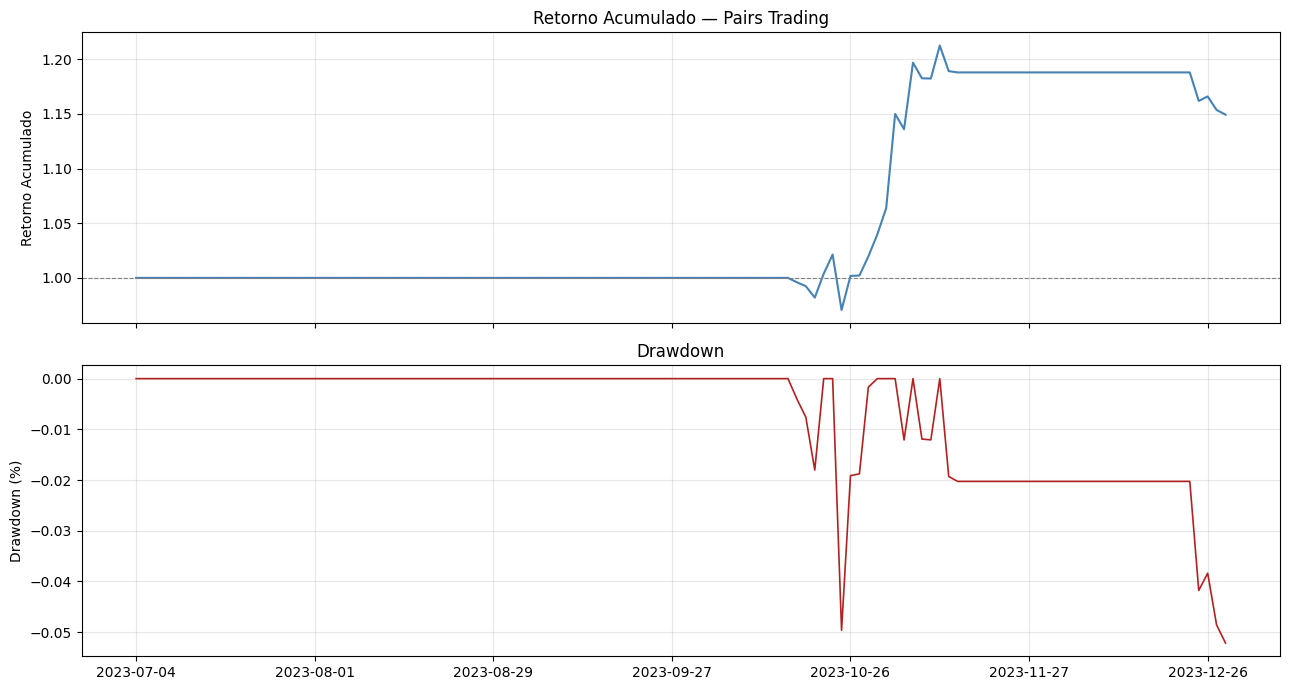

In [17]:
# ── Parâmetros da estratégia ──────────────────────────────────────────────────
ENTRADA   = 2.0
SAIDA     = 0.5
STOP_LOSS = 3.0
CUSTO     = 0.001

# ── Backtest ──────────────────────────────────────────────────────────────────
retornos_diarios = {}

for _, linha in df_pares_validos.iterrows():
    par_nome  = linha['Par']
    at1       = linha['Ativo 1']
    at2       = linha['Ativo 2']
    meia_vida = int(np.ceil(linha['Meia-Vida (Dias Úteis)']))

    col_z    = f"{par_nome}_Z-Score"
    col_beta = f"{par_nome}_Beta_Kalman"

    z    = df_historico_trading[col_z]
    beta = df_historico_trading[col_beta]
    p1   = df_trad[at1]
    p2   = df_trad[at2]

    posicao         = 0
    dias_em_posicao = 0
    retornos_par    = []
    datas           = []

    for i in range(1, len(z)):
        data      = z.index[i]
        z_hoje    = z.iloc[i]
        beta_hoje = beta.iloc[i]

        ret1 = p1.iloc[i] - p1.iloc[i - 1]
        ret2 = p2.iloc[i] - p2.iloc[i - 1]

        # ── Atualiza posição PRIMEIRO ─────────────────────────────────────────
        nova_posicao = posicao

        if posicao == 0:
            if z_hoje >= ENTRADA:
                nova_posicao    = -1
                dias_em_posicao = 0
            elif z_hoje <= -ENTRADA:
                nova_posicao    = +1
                dias_em_posicao = 0
        else:
            dias_em_posicao += 1
            if posicao == +1:
                if -SAIDA <= z_hoje <= SAIDA:
                    nova_posicao = 0   # saída normal
                elif z_hoje <= -STOP_LOSS:
                    nova_posicao = 0   # stop loss
                elif dias_em_posicao >= meia_vida:
                    nova_posicao = 0   # prazo máximo
            elif posicao == -1:
                if -SAIDA <= z_hoje <= SAIDA:
                    nova_posicao = 0   # saída normal
                elif z_hoje >= STOP_LOSS:
                    nova_posicao = 0   # stop loss
                elif dias_em_posicao >= meia_vida:
                    nova_posicao = 0   # prazo máximo

        if nova_posicao != posicao:
            dias_em_posicao = 0

        custo_dia = CUSTO if nova_posicao != posicao else 0.0
        posicao   = nova_posicao

        # ── Calcula retorno DEPOIS de atualizar posição ───────────────────────
        retorno_bruto   = posicao * (ret1 - beta_hoje * ret2)
        retorno_liquido = retorno_bruto - custo_dia

        retornos_par.append(retorno_liquido)
        datas.append(data)

    retornos_diarios[par_nome] = pd.Series(retornos_par, index=datas)

df_retornos = pd.DataFrame(retornos_diarios).fillna(0)

# ── Retorno da carteira com pesos iguais ──────────────────────────────────────
retorno_carteira  = df_retornos.mean(axis=1)
retorno_acumulado = (1 + retorno_carteira).cumprod()
pico              = retorno_acumulado.cummax()
drawdown          = (retorno_acumulado - pico) / pico
mdd               = drawdown.min()
sharpe            = (retorno_carteira.mean() / retorno_carteira.std()) * np.sqrt(252)

# ── Estatísticas ──────────────────────────────────────────────────────────────
print(f"═══ Estatísticas da Estratégia ══════════════════════════════════")
print(f"Pares operados            : {len(df_pares_validos)}")
print(f"Retorno acumulado líquido : {(retorno_acumulado.iloc[-1] - 1) * 100:.2f}%")
print(f"Retorno médio anualizado  : {retorno_carteira.mean() * 252 * 100:.2f}%")
print(f"Volatilidade anualizada   : {retorno_carteira.std() * np.sqrt(252) * 100:.2f}%")
print(f"Sharpe anualizado         : {sharpe:.4f}")
print(f"Maximum Drawdown          : {mdd * 100:.2f}%")

# ── Retorno por par ───────────────────────────────────────────────────────────
retorno_por_par = (1 + df_retornos).prod() - 1
retorno_por_par = retorno_por_par.sort_values()
print(f"\nRetorno acumulado por par:")
print((retorno_por_par * 100).round(2).to_string())
print(f"\nPares lucrativos: {(retorno_por_par > 0).sum()}")
print(f"Pares com perda : {(retorno_por_par < 0).sum()}")

# ── Gráfico ───────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

retorno_acumulado.plot(ax=axes[0], color='steelblue', linewidth=1.5)
axes[0].set_title('Retorno Acumulado — Pairs Trading')
axes[0].set_ylabel('Retorno Acumulado')
axes[0].axhline(1, color='gray', linestyle='--', linewidth=0.8)
axes[0].grid(True, alpha=0.3)

drawdown.plot(ax=axes[1], color='firebrick', linewidth=1.2)
axes[1].set_title('Drawdown')
axes[1].set_ylabel('Drawdown (%)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [47]:
# ── Exportação dos resultados do Período para Excel ───────────────────────────
ARQUIVO = "periodo_3_jul2022_dez2023.xlsx"

# ── Número total de trades ────────────────────────────────────────────────────
total_trades = 0
for par in df_pares_validos['Par']:
    col_z = f"{par}_Z-Score"
    if col_z not in df_historico_trading.columns:
        continue
    z = df_historico_trading[col_z]
    posicao = 0
    dias_em_posicao = 0
    meia_vida_par = int(np.ceil(
        df_pares_validos.loc[df_pares_validos['Par'] == par, 'Meia-Vida (Dias Úteis)'].values[0]
    ))
    for z_atual in z:
        nova_posicao = posicao
        if posicao == 0:
            if z_atual >= ENTRADA:
                nova_posicao = -1; dias_em_posicao = 0
            elif z_atual <= -ENTRADA:
                nova_posicao = +1; dias_em_posicao = 0
        else:
            dias_em_posicao += 1
            if posicao == +1:
                if -SAIDA <= z_atual <= SAIDA or z_atual <= -STOP_LOSS or dias_em_posicao >= meia_vida_par:
                    nova_posicao = 0
            elif posicao == -1:
                if -SAIDA <= z_atual <= SAIDA or z_atual >= STOP_LOSS or dias_em_posicao >= meia_vida_par:
                    nova_posicao = 0
        if nova_posicao == 0 and posicao != 0:
            total_trades += 1
            dias_em_posicao = 0
        posicao = nova_posicao

# ── Aba 5: Estatísticas resumidas ─────────────────────────────────────────────
df_estatisticas = pd.DataFrame([{
    'Período de Estimação'       : 'Jul/2021 – Jun/2022',
    'Período de Trading'         : 'Jul/2022 – Dez/2022',
    'Pares Operados'             : len(df_pares_validos),
    'Total de Trades'            : total_trades,
    'Retorno Acumulado (%)'      : round((retorno_acumulado.iloc[-1] - 1) * 100, 2),
    'Retorno Anualizado (%)'     : round(retorno_carteira.mean() * 252 * 100, 2),
    'Volatilidade Anualizada (%)': round(retorno_carteira.std() * np.sqrt(252) * 100, 2),
    'Sharpe Anualizado'          : round(sharpe, 4),
    'Maximum Drawdown (%)'       : round(mdd * 100, 2),
}])

# ── Aba 4: Retorno diário da carteira + acumulado ─────────────────────────────
df_retorno_carteira = pd.DataFrame({
    'Retorno Diário'    : retorno_carteira,
    'Retorno Acumulado' : retorno_acumulado,
    'Drawdown'          : drawdown,
})

# ── Corrige zeros negativos nos retornos por par ──────────────────────────────
df_retornos_limpo = df_retornos.round(8)

# ── Exporta para Excel com múltiplas abas ─────────────────────────────────────
with pd.ExcelWriter(ARQUIVO, engine='openpyxl') as writer:

    # Aba 1 — Pares selecionados
    df_pares_validos.to_excel(
        writer, sheet_name='1_Pares_Selecionados', index=False)

    # Aba 2 — Z-scores do período de trading
    df_historico_trading[
        [c for c in df_historico_trading.columns if '_Z-Score' in c]
    ].to_excel(writer, sheet_name='2_ZScores_Trading')

    # Aba 3 — Retornos diários por par (sem zeros negativos)
    df_retornos_limpo.to_excel(writer, sheet_name='3_Retornos_Por_Par')

    # Aba 4 — Retorno da carteira
    df_retorno_carteira.to_excel(writer, sheet_name='4_Retorno_Carteira')

    # Aba 5 — Estatísticas resumidas
    df_estatisticas.to_excel(
        writer, sheet_name='5_Estatisticas', index=False)

print(f"Arquivo '{ARQUIVO}' salvo com sucesso!")
print(f"\nAbas geradas:")
print(f"  1_Pares_Selecionados : {len(df_pares_validos)} pares")
print(f"  2_ZScores_Trading    : {len([c for c in df_historico_trading.columns if '_Z-Score' in c])} séries")
print(f"  3_Retornos_Por_Par   : {df_retornos_limpo.shape[1]} pares × {df_retornos_limpo.shape[0]} dias")
print(f"  4_Retorno_Carteira   : {len(df_retorno_carteira)} dias")
print(f"  5_Estatisticas       : {total_trades} trades no período")

Arquivo 'periodo_3_jul2022_dez2023.xlsx' salvo com sucesso!

Abas geradas:
  1_Pares_Selecionados : 2 pares
  2_ZScores_Trading    : 10 séries
  3_Retornos_Por_Par   : 2 pares × 123 dias
  4_Retorno_Carteira   : 123 dias
  5_Estatisticas       : 2 trades no período
